In [3]:
import numpy as np
import pandas as pd
import random
import torch
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# =========================
# LOAD DATA
# =========================
DATA_PATH = "data/Thyroid_Diff.csv"
df = pd.read_csv(DATA_PATH, encoding="latin1")

target_col = df.columns[-1]
X = df.drop(columns=[target_col])
y = df[target_col]

# Encode categorical
for col in X.select_dtypes(include="object"):
    X[col] = LabelEncoder().fit_transform(X[col])

if y.dtype == "object":
    y = LabelEncoder().fit_transform(y)

X = StandardScaler().fit_transform(X)

# =========================
# FAST FSRO IMPLEMENTATION
# =========================
def enforce_min_features(mask, min_features):
    if mask.sum() >= min_features:
        return mask
    zeros = np.where(mask == 0)[0]
    mask[np.random.choice(zeros, min_features - mask.sum(), replace=False)] = 1
    return mask


def fsro_feature_selection(
    X, y,
    pop_size=12,
    iters=12,
    min_features=9,
    alpha=0.99
):
    n_features = X.shape[1]
    best_score = -np.inf
    best_mask = None
    cache = {}

    X_tr, X_val, y_tr, y_val = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=42
    )

    population = []
    for _ in range(pop_size):
        mask = np.random.randint(0, 2, n_features)
        mask = enforce_min_features(mask, min_features)
        population.append(mask)

    for it in range(iters):
        for i in range(pop_size):
            mask = population[i].copy()
            idx = np.random.randint(0, n_features)
            mask[idx] ^= 1
            mask = enforce_min_features(mask, min_features)

            key = tuple(mask)
            if key in cache:
                fitness = cache[key]
            else:
                Xtr_sel = X_tr[:, mask == 1]
                Xval_sel = X_val[:, mask == 1]

                clf = RandomForestClassifier(
                    n_estimators=60,   # 🔥 reduced
                    random_state=42,
                    n_jobs=-1
                )
                clf.fit(Xtr_sel, y_tr)
                acc = accuracy_score(y_val, clf.predict(Xval_sel))

                fitness = alpha * acc + (1 - alpha) * (1 - Xtr_sel.shape[1] / n_features)
                cache[key] = fitness

            if fitness > best_score:
                best_score = fitness
                best_mask = mask.copy()

            population[i] = mask

        print(f"Iteration {it+1}/{iters} | Best fitness: {best_score:.4f}")

    return best_mask


# =========================
# APPLY FSRO
# =========================
min_features = 9

best_mask = fsro_feature_selection(
    X, y,
    pop_size=12,
    iters=12,
    min_features=min_features
)

X = X[:, best_mask == 1]

print("✅ Selected features:", X.shape[1])
assert X.shape[1] >= min_features
plt.tight_layout()

plt.savefig("Fig2_FSRO_Convergence.pdf", bbox_inches="tight")

plt.savefig("Fig2_FSRO_Convergence.png",
            dpi=600,
            bbox_inches="tight",
            facecolor="white")

plt.show()



Iteration 1/12 | Best fitness: 0.9738
Iteration 2/12 | Best fitness: 0.9738
Iteration 3/12 | Best fitness: 0.9738
Iteration 4/12 | Best fitness: 0.9738
Iteration 5/12 | Best fitness: 0.9738
Iteration 6/12 | Best fitness: 0.9738
Iteration 7/12 | Best fitness: 0.9738
Iteration 8/12 | Best fitness: 0.9822
Iteration 9/12 | Best fitness: 0.9822
Iteration 10/12 | Best fitness: 0.9822
Iteration 11/12 | Best fitness: 0.9822
Iteration 12/12 | Best fitness: 0.9822
✅ Selected features: 12


<Figure size 640x480 with 0 Axes>

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


In [6]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

boost_models = {
    "XGBoost": XGBClassifier(eval_metric="mlogloss", random_state=SEED),
    "LightGBM": LGBMClassifier(verbosity=-1, random_state=SEED),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=SEED)
}

trained_boost = {}

for name, model in boost_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"\n{name}")
    print(classification_report(y_test, preds))
    trained_boost[name] = model



XGBoost
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        55
           1       0.95      0.91      0.93        22

    accuracy                           0.96        77
   macro avg       0.96      0.95      0.95        77
weighted avg       0.96      0.96      0.96        77


LightGBM
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        55
           1       1.00      0.91      0.95        22

    accuracy                           0.97        77
   macro avg       0.98      0.95      0.97        77
weighted avg       0.97      0.97      0.97        77


CatBoost
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        55
           1       1.00      0.91      0.95        22

    accuracy                           0.97        77
   macro avg       0.98      0.95      0.97        77
weighted avg       0.97      0.97      0.97  

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=7))
    ]),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.5,
        random_state=42
    )
}
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, preds))
    print(classification_report(y_test, preds))

    trained_models[name] = model



Logistic Regression
Accuracy: 0.922077922077922
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        55
           1       0.86      0.86      0.86        22

    accuracy                           0.92        77
   macro avg       0.90      0.90      0.90        77
weighted avg       0.92      0.92      0.92        77


SVM
Accuracy: 0.948051948051948
              precision    recall  f1-score   support

           0       0.95      0.98      0.96        55
           1       0.95      0.86      0.90        22

    accuracy                           0.95        77
   macro avg       0.95      0.92      0.93        77
weighted avg       0.95      0.95      0.95        77


KNN
Accuracy: 0.935064935064935
              precision    recall  f1-score   support

           0       0.93      0.98      0.96        55
           1       0.95      0.82      0.88        22

    accuracy                           0.94        77
   macro avg 

In [8]:
from pytorch_tabnet.tab_model import TabNetClassifier

tabnet = TabNetClassifier(verbose=0)
tabnet.fit(X_train, y_train, max_epochs=200, patience=30)
print("\nTabNet")
print(classification_report(y_test, tabnet.predict(X_test)))



TabNet
              precision    recall  f1-score   support

           0       0.71      1.00      0.83        55
           1       0.00      0.00      0.00        22

    accuracy                           0.71        77
   macro avg       0.36      0.50      0.42        77
weighted avg       0.51      0.71      0.60        77



In [9]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

device = "cuda" if torch.cuda.is_available() else "cpu"

# Convert to torch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
y_test_t  = torch.tensor(y_test,  dtype=torch.long).to(device)

n_classes = len(np.unique(y_train))


In [10]:
from rtdl_revisiting_models import FTTransformer

ft = FTTransformer(
    n_cont_features=X_train.shape[1],
    cat_cardinalities=[],        # no categorical features
    d_out=n_classes,

    n_blocks=4,
    d_block=128,
    attention_n_heads=8,

    attention_dropout=0.1,
    ffn_d_hidden_multiplier=2,
    ffn_dropout=0.1,
    residual_dropout=0.1
).to(device)

optimizer = torch.optim.AdamW(ft.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# ---- TRAIN ----
for epoch in range(30):
    optimizer.zero_grad()
    logits = ft(X_train_t, None)   # IMPORTANT: x_cat = None
    loss = criterion(logits, y_train_t)
    loss.backward()
    optimizer.step()

# ---- EVALUATE ----
ft.eval()
with torch.no_grad():
    preds = ft(X_test_t, None).argmax(1).cpu().numpy()

print("\nFT-Transformer")
print("Accuracy :", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds, average="weighted"))
print("Recall   :", recall_score(y_test, preds, average="weighted"))
print("F1-score :", f1_score(y_test, preds, average="weighted"))
print(classification_report(y_test, preds))



FT-Transformer
Accuracy : 0.974025974025974
Precision: 0.974937343358396
Recall   : 0.974025974025974
F1-score : 0.9736394557823128
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        55
           1       1.00      0.91      0.95        22

    accuracy                           0.97        77
   macro avg       0.98      0.95      0.97        77
weighted avg       0.97      0.97      0.97        77



In [11]:
import numpy as np
import torch
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# =============================
# TABNET MODEL
# =============================
tabnet = TabNetClassifier(
    n_d=32,
    n_a=32,
    n_steps=5,
    gamma=1.5,
    n_independent=2,
    n_shared=2,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    mask_type="entmax",
    verbose=10,
    seed=42
)

# =============================
# TRAIN
# =============================
tabnet.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_name=["val"],
    eval_metric=["accuracy"],
    max_epochs=300,
    patience=50,
    batch_size=256,
    virtual_batch_size=128,
    drop_last=False
)


# =============================
# EVALUATION
# =============================
y_pred = tabnet.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted")
rec = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("\n✅ TABNET RESULTS")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


epoch 0  | loss: 1.38943 | val_accuracy: 0.76623 |  0:00:00s
epoch 10 | loss: 0.11727 | val_accuracy: 0.87013 |  0:00:01s
epoch 20 | loss: 0.10854 | val_accuracy: 0.93506 |  0:00:02s
epoch 30 | loss: 0.03734 | val_accuracy: 0.94805 |  0:00:04s
epoch 40 | loss: 0.06999 | val_accuracy: 0.97403 |  0:00:05s
epoch 50 | loss: 0.0532  | val_accuracy: 0.96104 |  0:00:06s
epoch 60 | loss: 0.03835 | val_accuracy: 0.96104 |  0:00:08s
epoch 70 | loss: 0.02696 | val_accuracy: 0.94805 |  0:00:09s
epoch 80 | loss: 0.03421 | val_accuracy: 0.96104 |  0:00:10s

Early stopping occurred at epoch 86 with best_epoch = 36 and best_val_accuracy = 0.97403

✅ TABNET RESULTS
Accuracy : 0.9740
Precision: 0.9749
Recall   : 0.9740
F1 Score : 0.9736

Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        55
           1       1.00      0.91      0.95        22

    accuracy                           0.97        77
   macro avg       0.98     

In [12]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stack = StackingClassifier(
    estimators=[
        ("xgb", trained_boost["XGBoost"]),
        ("lgbm", trained_boost["LightGBM"]),
        ("cat", trained_boost["CatBoost"])
    ],
    final_estimator=LogisticRegression(max_iter=500),
    cv=5
)

stack.fit(X_train, y_train)
print("\nSTACKING ENSEMBLE (FINAL)")
print(classification_report(y_test, stack.predict(X_test)))



STACKING ENSEMBLE (FINAL)
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        55
           1       1.00      0.91      0.95        22

    accuracy                           0.97        77
   macro avg       0.98      0.95      0.97        77
weighted avg       0.97      0.97      0.97        77



In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


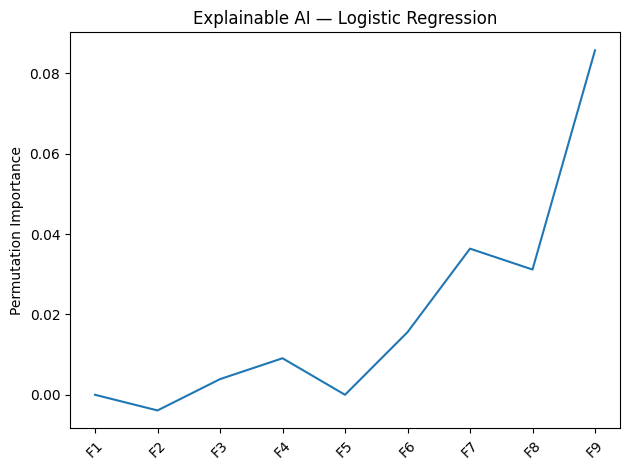

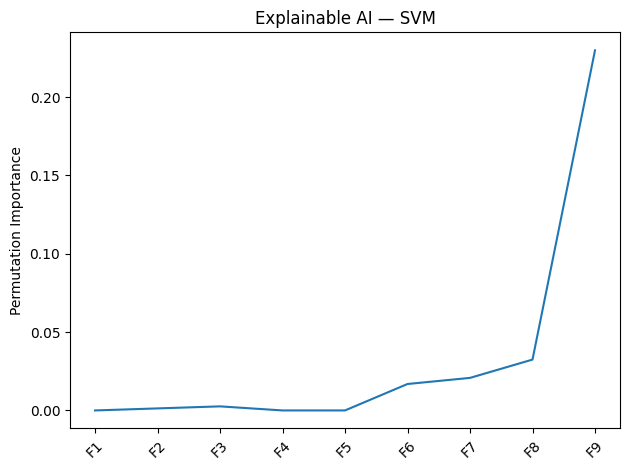

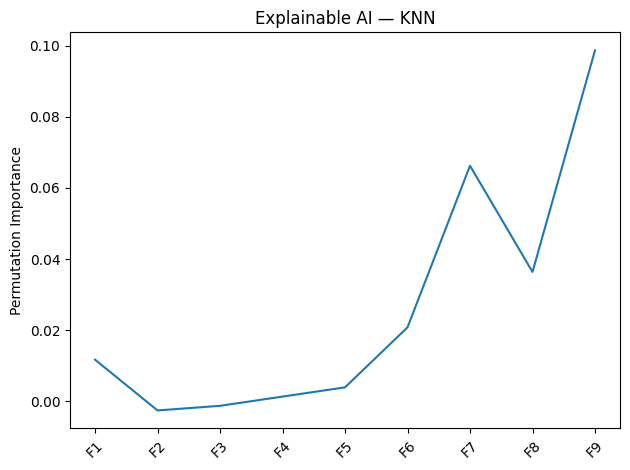

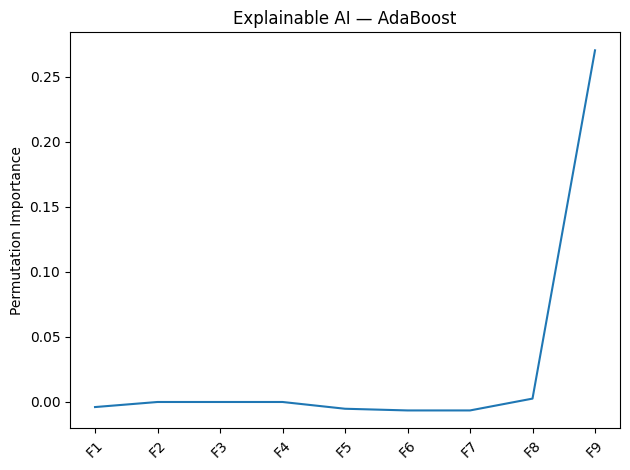

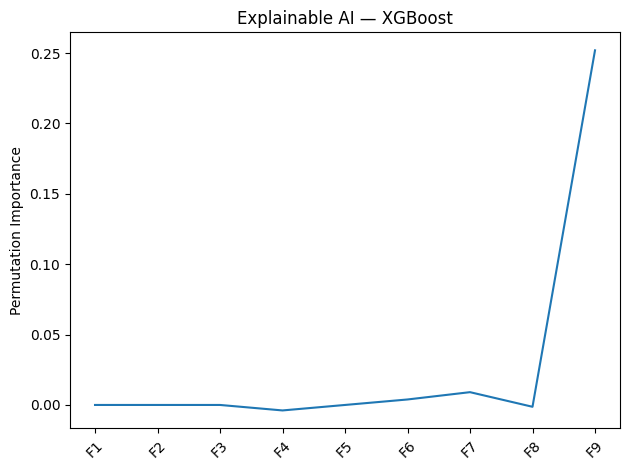

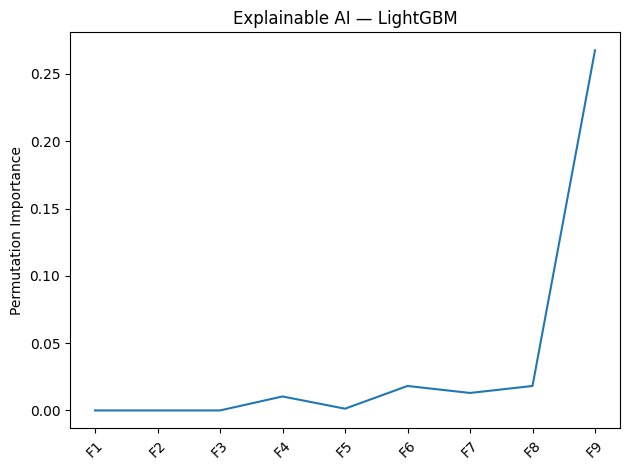

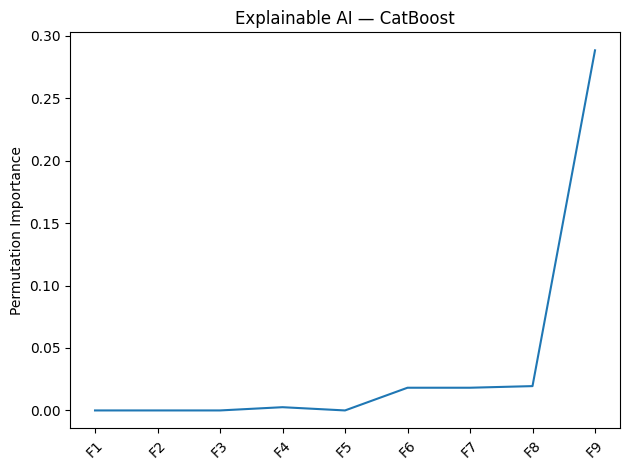

In [14]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np

# feature names (since X is numpy)
features = [f"F{i+1}" for i in range(X_train.shape[1])]

# combine all models
all_models = {}
all_models.update(trained_models)
all_models.update(trained_boost)

for name, model in all_models.items():
    
    r = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=10,
        random_state=42
    )

    importances = r.importances_mean

    plt.figure()
    plt.plot(range(len(features)), importances)
    plt.xticks(range(len(features)), features, rotation=45)
    plt.ylabel("Permutation Importance")
    plt.title(f"Explainable AI — {name}")
    plt.tight_layout()
    plt.show()


In [15]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay

from pytorch_tabnet.tab_model import TabNetClassifier
from lime.lime_tabular import LimeTabularExplainer
import dice_ml


In [16]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv(r"C:\Users\ADITYA SHENOY\Downloads\differentiated+thyroid+cancer+recurrence\Thyroid_Diff.csv")

# Encode every object-type column
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Now split
X = df.drop("Recurred", axis=1)
y = df["Recurred"]


epoch 0  | loss: 1.02658 | train_accuracy: 0.38235 | valid_accuracy: 0.38961 |  0:00:00s
epoch 1  | loss: 0.53204 | train_accuracy: 0.61765 | valid_accuracy: 0.58442 |  0:00:00s
epoch 2  | loss: 0.48264 | train_accuracy: 0.77778 | valid_accuracy: 0.75325 |  0:00:00s
epoch 3  | loss: 0.42272 | train_accuracy: 0.83007 | valid_accuracy: 0.85714 |  0:00:00s
epoch 4  | loss: 0.33679 | train_accuracy: 0.8268  | valid_accuracy: 0.84416 |  0:00:00s
epoch 5  | loss: 0.23171 | train_accuracy: 0.84314 | valid_accuracy: 0.84416 |  0:00:00s
epoch 6  | loss: 0.17697 | train_accuracy: 0.88562 | valid_accuracy: 0.85714 |  0:00:00s
epoch 7  | loss: 0.23078 | train_accuracy: 0.90523 | valid_accuracy: 0.88312 |  0:00:01s
epoch 8  | loss: 0.197   | train_accuracy: 0.91503 | valid_accuracy: 0.8961  |  0:00:01s
epoch 9  | loss: 0.20272 | train_accuracy: 0.91503 | valid_accuracy: 0.88312 |  0:00:01s
epoch 10 | loss: 0.12785 | train_accuracy: 0.9183  | valid_accuracy: 0.85714 |  0:00:01s
epoch 11 | loss: 0.15

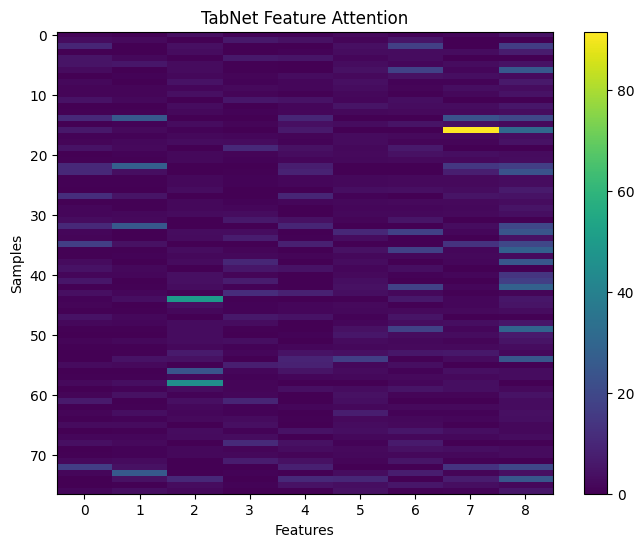

In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import accuracy_score
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# =========================
# FINAL TUNED TABNET MODEL
# =========================

tabnet = TabNetClassifier(
    n_d=32,
    n_a=32,
    n_steps=5,
    gamma=1.5,
    lambda_sparse=1e-4,
    optimizer_params=dict(lr=1e-2),
    mask_type='entmax',
    scheduler_params={
        "step_size":20,
        "gamma":0.9
    },
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    verbose=1
)

# =========================
# TRAIN MODEL
# =========================

tabnet.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_name=['train', 'valid'],
    eval_metric=['accuracy'],
    max_epochs=200,
    patience=50,
    batch_size=256,
    virtual_batch_size=128
)

# =========================
# PREDICTIONS
# =========================

preds = tabnet.predict(X_test)

acc = accuracy_score(y_test, preds)
print("Final TabNet Accuracy:", acc)

# =========================
# FEATURE ATTENTION MAP
# =========================

explain_matrix, masks = tabnet.explain(X_test)

plt.figure(figsize=(8,6))
plt.imshow(explain_matrix[:100], aspect='auto')
plt.title("TabNet Feature Attention")
plt.xlabel("Features")
plt.ylabel("Samples")
plt.colorbar()
plt.show()

In [18]:
perm = permutation_importance(
    tabnet,
    X_test,
    y_test,
    scoring="accuracy",  
    n_repeats=10,
    random_state=42
)



ExactExplainer explainer: 78it [03:26,  2.69s/it]                                                                      


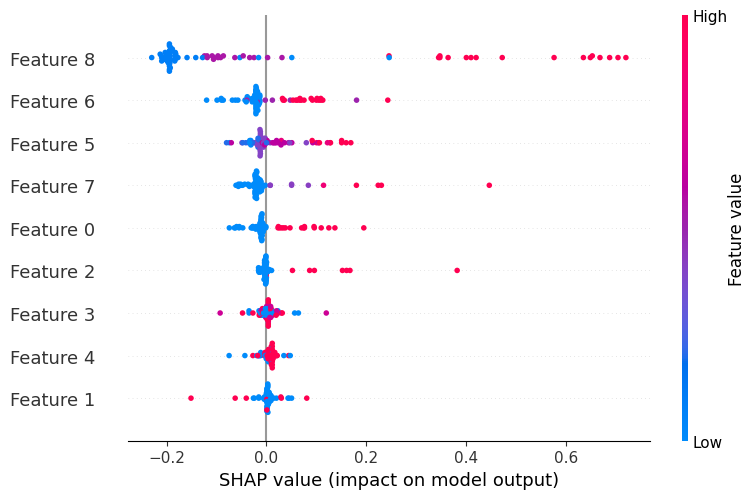

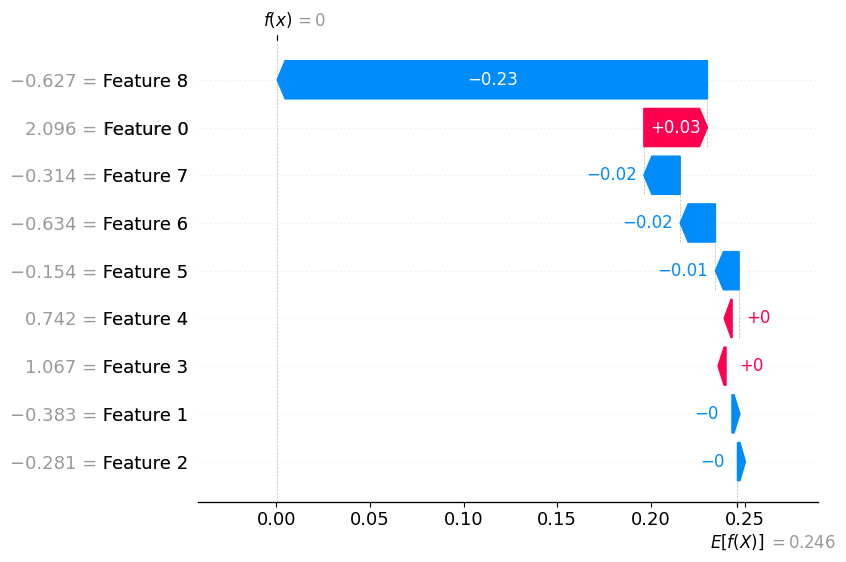

In [19]:
explainer = shap.Explainer(tabnet.predict_proba, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values[:,:,1], X_test)
shap.plots.waterfall(shap_values[0,:,1])



LIME Feature Contributions:

Feature_9 <= -0.63: -0.3552
Feature_7 <= -0.63: -0.1650
Feature_8 <= -0.31: -0.1624
Feature_1 > -0.48: 0.1503
Feature_3 <= -0.28: -0.1460
Feature_2 <= -0.38: 0.0614
Feature_6 <= -0.15: -0.0573
-1.35 < Feature_5 <= 0.74: -0.0436
0.33 < Feature_4 <= 1.07: 0.0006


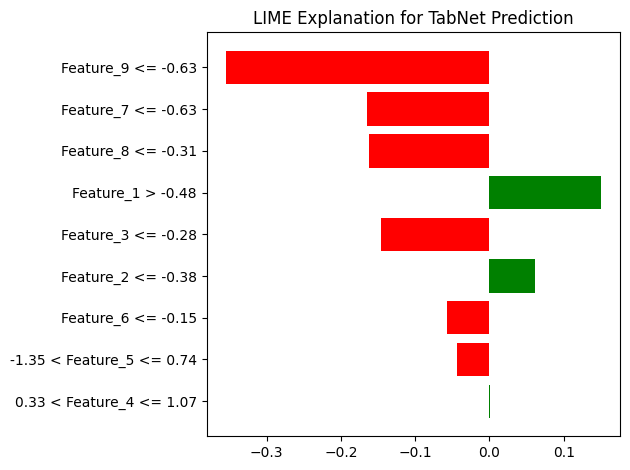


LIME explanation saved as 'lime_explanation.html'


In [33]:
# =========================
# LIME EXPLANATION FOR TUNED TABNET
# =========================

import numpy as np
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer

# -------------------------
# Convert to NumPy safely
# -------------------------

Xtr = X_train.values if hasattr(X_train, "values") else np.array(X_train)
Xte = X_test.values if hasattr(X_test, "values") else np.array(X_test)

# -------------------------
# Feature Names
# -------------------------

feature_names = [f"Feature_{i+1}" for i in range(Xtr.shape[1])]

# -------------------------
# LIME Explainer
# -------------------------

lime_exp = LimeTabularExplainer(
    training_data=Xtr,
    feature_names=feature_names,
    class_names=["No Recurrence", "Recurrence"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

# -------------------------
# Prediction Function
# -------------------------

def predict_fn(x):
    return tabnet.predict_proba(x)

# -------------------------
# Select Instance
# -------------------------

instance = Xte[0]

# -------------------------
# Generate Explanation
# -------------------------

exp = lime_exp.explain_instance(
    data_row=instance,
    predict_fn=predict_fn,
    num_features=min(9, Xtr.shape[1])
)

# -------------------------
# PRINT FEATURE CONTRIBUTIONS
# -------------------------

print("\nLIME Feature Contributions:\n")

for feature, weight in exp.as_list():
    print(f"{feature}: {weight:.4f}")

# -------------------------
# PLOT EXPLANATION
# -------------------------

fig = exp.as_pyplot_figure()

plt.title("LIME Explanation for TabNet Prediction")
plt.tight_layout()
plt.show()

# -------------------------
# SAVE HTML
# -------------------------

exp.save_to_file("lime_explanation.html")

print("\nLIME explanation saved as 'lime_explanation.html'")

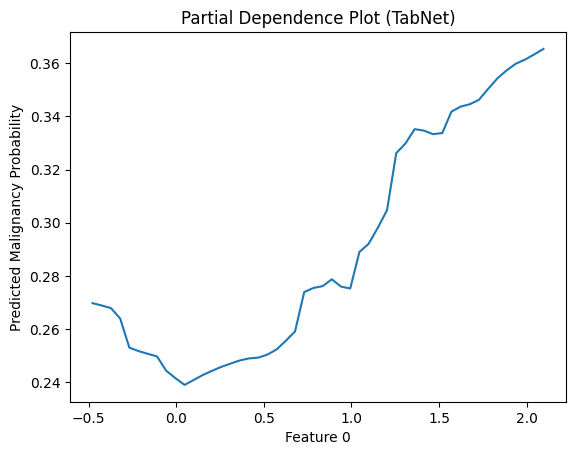

In [25]:
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance

def tabnet_scorer(model, X, y):
    preds = model.predict(X)
    return accuracy_score(y, preds)

perm = permutation_importance(
    tabnet,
    X_test,
    y_test,
    scoring=tabnet_scorer,
    n_repeats=10,
    random_state=42
)
import numpy as np
import matplotlib.pyplot as plt

feature_index = 0   # change to any feature index
values = np.linspace(X_test[:, feature_index].min(),
                     X_test[:, feature_index].max(), 50)

avg_preds = []

X_temp = X_test.copy()

for v in values:
    X_temp[:, feature_index] = v
    probs = tabnet.predict_proba(X_temp)[:,1]
    avg_preds.append(probs.mean())

plt.plot(values, avg_preds)
plt.xlabel(f"Feature {feature_index}")
plt.ylabel("Predicted Malignancy Probability")
plt.title("Partial Dependence Plot (TabNet)")
plt.show()



In [26]:
class TabNetWrapper:
    def __init__(self, model):
        self.model = model

    def predict_proba(self, X):
        import numpy as np
        if isinstance(X, pd.DataFrame):
            X = X.to_numpy()
        return self.model.predict_proba(X)

    def predict(self, X):
        import numpy as np
        if isinstance(X, pd.DataFrame):
            X = X.to_numpy()
        return self.model.predict(X)


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.30it/s]

Query instance (original outcome : 0)


,F0,F1,F2,F3,F4,F5,F6,F7,F8,Recurred
0,2.096274,-0.383023,-0.280844,1.066968,0.742029,-0.153597,-0.633987,-0.314426,-0.626824,0



Diverse Counterfactual set (new outcome: 1)


,F0,F1,F2,F3,F4,F5,F6,F7,F8,Recurred
0,2.096274,-0.383023,-0.280844,1.066968,0.742029,-0.153597,-0.633987,-0.314426,1.021112,1
1,2.096274,-0.383023,-0.280844,1.066968,0.742029,1.076098,1.427428,-0.314426,-0.626824,1


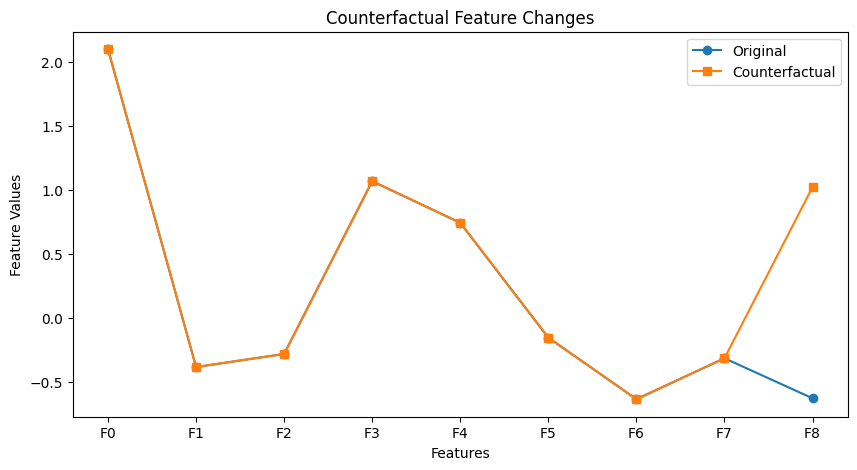

In [31]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier()
lgbm.fit(X_train, y_train)

import pandas as pd
import numpy as np
import dice_ml

# Feature names
feature_names = [f"F{i}" for i in range(X_train.shape[1])]

# Dataframe
data_df = pd.DataFrame(X_train, columns=feature_names)
data_df["Recurred"] = y_train

# DiCE data object
d = dice_ml.Data(
    dataframe=data_df,
    continuous_features=feature_names,
    outcome_name="Recurred"
)

# Use LightGBM instead
m = dice_ml.Model(
    model=lgbm,
    backend="sklearn"
)

dice = dice_ml.Dice(d, m)

# Query instance
query_instance = pd.DataFrame(
    [X_test[0]],
    columns=feature_names
)

# Generate counterfactuals
cf = dice.generate_counterfactuals(
    query_instance,
    total_CFs=2,
    desired_class="opposite"
)

cf.visualize_as_dataframe()
import matplotlib.pyplot as plt

# Original instance
original = query_instance.iloc[0]

# Counterfactual instance
cf_df = cf.cf_examples_list[0].final_cfs_df
counterfactual = cf_df.iloc[0][feature_names]

# Plot comparison
plt.figure(figsize=(10,5))

x = range(len(feature_names))

plt.plot(x, original.values, marker='o', label='Original')
plt.plot(x, counterfactual.values, marker='s', label='Counterfactual')

plt.xticks(x, feature_names)
plt.xlabel("Features")
plt.ylabel("Feature Values")
plt.title("Counterfactual Feature Changes")
plt.legend()

plt.show()


LIME Explanation:

F8 <= -0.63: -0.3351
F7 <= -0.31: -0.1895
F2 <= -0.28: -0.1878
F0 > -0.48: 0.1563
F6 <= -0.63: -0.1474
F5 <= -0.15: -0.0680
F1 <= -0.38: 0.0608
-1.35 < F4 <= 0.74: -0.0564
0.33 < F3 <= 1.07: -0.0199


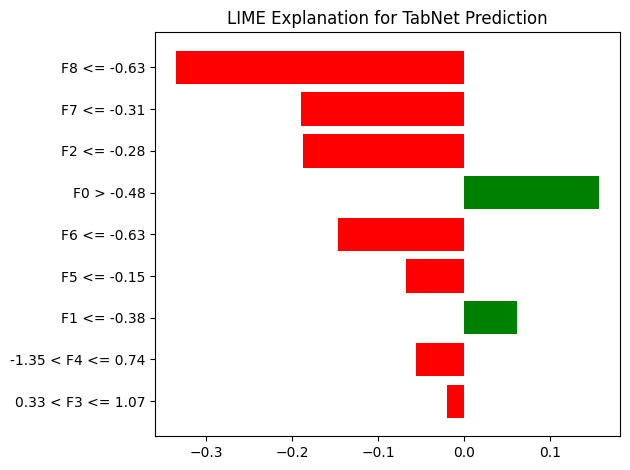

In [32]:
# =========================
# LIME FOR TUNED TABNET
# =========================

import numpy as np
import matplotlib.pyplot as plt

from lime.lime_tabular import LimeTabularExplainer

# -------------------------
# Feature names
# -------------------------

feature_names = [f"F{i}" for i in range(X_train.shape[1])]

# -------------------------
# LIME Explainer
# -------------------------

explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=feature_names,
    class_names=["Benign", "Malignant"],
    mode="classification"
)

# -------------------------
# Prediction Function
# -------------------------

def predict_fn(x):
    return tabnet.predict_proba(x)

# -------------------------
# Select Test Instance
# -------------------------

instance = np.array(X_test[0])

# -------------------------
# Generate Explanation
# -------------------------

exp = explainer.explain_instance(
    data_row=instance,
    predict_fn=predict_fn,
    num_features=9
)

# -------------------------
# SHOW TEXT EXPLANATION
# -------------------------

print("\nLIME Explanation:\n")
for feature, weight in exp.as_list():
    print(f"{feature}: {weight:.4f}")

# -------------------------
# PLOT LIME
# -------------------------

fig = exp.as_pyplot_figure()

plt.title("LIME Explanation for TabNet Prediction")
plt.tight_layout()
plt.show()

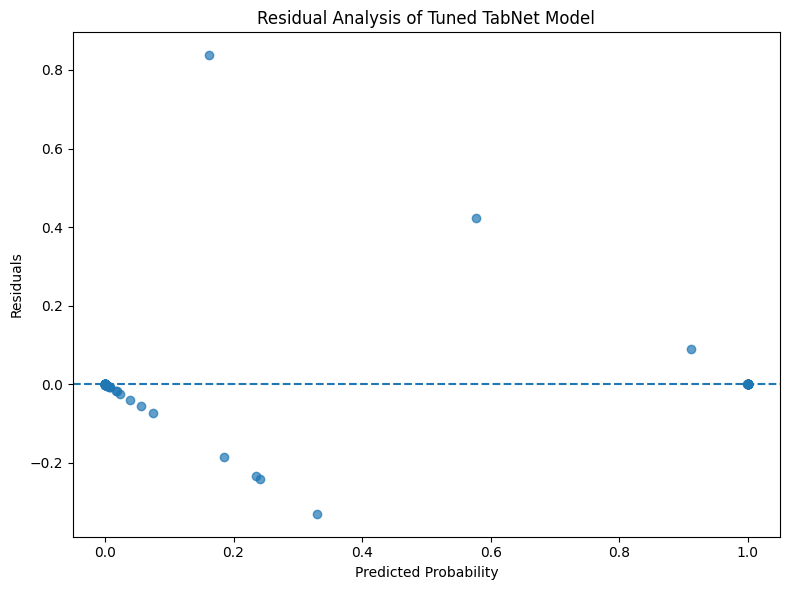

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PREDICT PROBABILITIES
# =========================

probs = tabnet.predict_proba(X_test)[:, 1]

# =========================
# RESIDUALS
# =========================

residuals = y_test - probs

# =========================
# RESIDUAL PLOT
# =========================

plt.figure(figsize=(8,6))

plt.scatter(
    probs,
    residuals,
    alpha=0.7
)

# Horizontal zero-error line
plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Probability")
plt.ylabel("Residuals")
plt.title("Residual Analysis of Tuned TabNet Model")

plt.tight_layout()
plt.show()

In [ ]:
print(X_train.shape)
print(X.shape)


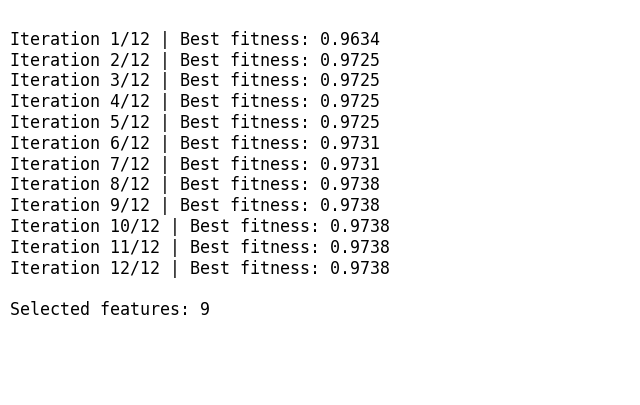

In [3]:
import matplotlib.pyplot as plt

output = """
Iteration 1/12 | Best fitness: 0.9634
Iteration 2/12 | Best fitness: 0.9725
Iteration 3/12 | Best fitness: 0.9725
Iteration 4/12 | Best fitness: 0.9725
Iteration 5/12 | Best fitness: 0.9725
Iteration 6/12 | Best fitness: 0.9731
Iteration 7/12 | Best fitness: 0.9731
Iteration 8/12 | Best fitness: 0.9738
Iteration 9/12 | Best fitness: 0.9738
Iteration 10/12 | Best fitness: 0.9738
Iteration 11/12 | Best fitness: 0.9738
Iteration 12/12 | Best fitness: 0.9738

Selected features: 9
"""

plt.figure(figsize=(8,5))
plt.axis("off")
plt.text(
    0,
    1,
    output,
    family="monospace",
    fontsize=12,
    va="top"
)

plt.savefig("FSRO_Output.png", dpi=600, bbox_inches="tight")
plt.show()